Name:Somalaraju Rohini
Reg No:212224240156


Salary Dataset:
   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0
5              2.9  56642.0
6              3.0  60150.0
7              3.2  54445.0
8              3.2  64445.0
9              3.7  57189.0


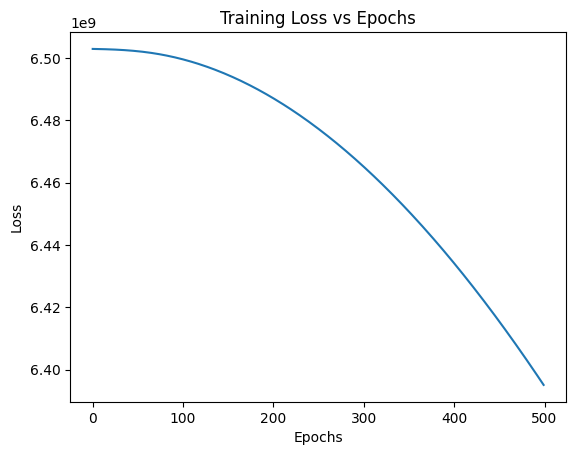


New Sample Data Prediction
tensor([[847.9443]], grad_fn=<AddmmBackward0>)


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("Salary_Data.csv")

print("\nSalary Dataset:")
print(data.head(10))

X = torch.tensor(data.iloc[:, 0].values, dtype=torch.float32).view(-1, 1)
Y = torch.tensor(data.iloc[:, 1].values, dtype=torch.float32).view(-1, 1)

X = X / X.max()

class SalaryPredictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 10)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(10, 1)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SalaryPredictor()

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)


losses = []

for epoch in range(500):
    optimizer.zero_grad()
    output = model(X)
    loss = criterion(output, Y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())


plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.show()

print("\nNew Sample Data Prediction")

sample = torch.tensor([[0.9]], dtype=torch.float32)
prediction = model(sample)

print(prediction)
